In [130]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler


In [131]:
red_wine = pd.read_csv('winequality-red.csv', sep=';')
red_wine.head()
columns  = red_wine.columns.tolist()
columns.remove('quality')
X = red_wine[columns]
y = red_wine['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

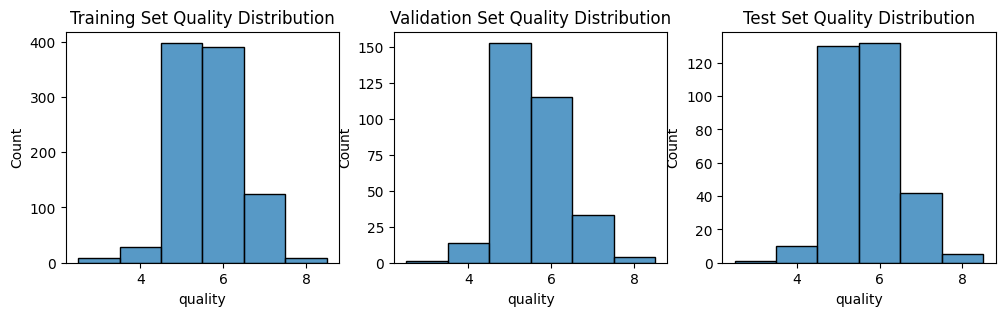

In [132]:
# Plot the distribution of quality scores in the training, validation, and test sets
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
sns.histplot(y_train, bins=np.arange(2.5, 9.5, 1), ax=axes[0], kde=False)
axes[0].set_title('Training Set Quality Distribution')
sns.histplot(y_val, bins=np.arange(2.5, 9.5, 1), ax=axes[1], kde=False)
axes[1].set_title('Validation Set Quality Distribution')
sns.histplot(y_test, bins=np.arange(2.5, 9.5, 1), ax=axes[2], kde=False)
axes[2].set_title('Test Set Quality Distribution')
plt.show()

In [133]:
# Start with a simple linear regression model
model_linear = LinearRegression()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
model_linear.fit(X_train_scaled, y_train)
y_val_pred = model_linear.predict(X_val_scaled)
val_mse = np.mean((y_val - y_val_pred) ** 2)
print(f'Validation MSE: {val_mse:.4f}')

Validation MSE: 0.4547


In [134]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
ridge_model = Ridge(alpha=1*len(X_train))
ridge_model.fit(X_train_scaled, y_train)
y_val_pred_ridge = ridge_model.predict(X_val_scaled)
val_mse_ridge = np.mean((y_val - y_val_pred_ridge) ** 2)
print(f'Ridge Validation MSE: {val_mse_ridge:.4f}')

Ridge Validation MSE: 0.4747


In [135]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
y_val_pred_lasso = lasso_model.predict(X_val_scaled)
val_mse_lasso = np.mean((y_val - y_val_pred_lasso) ** 2)
print(f'Lasso Validation MSE: {val_mse_lasso:.4f}')

Lasso Validation MSE: 0.4824


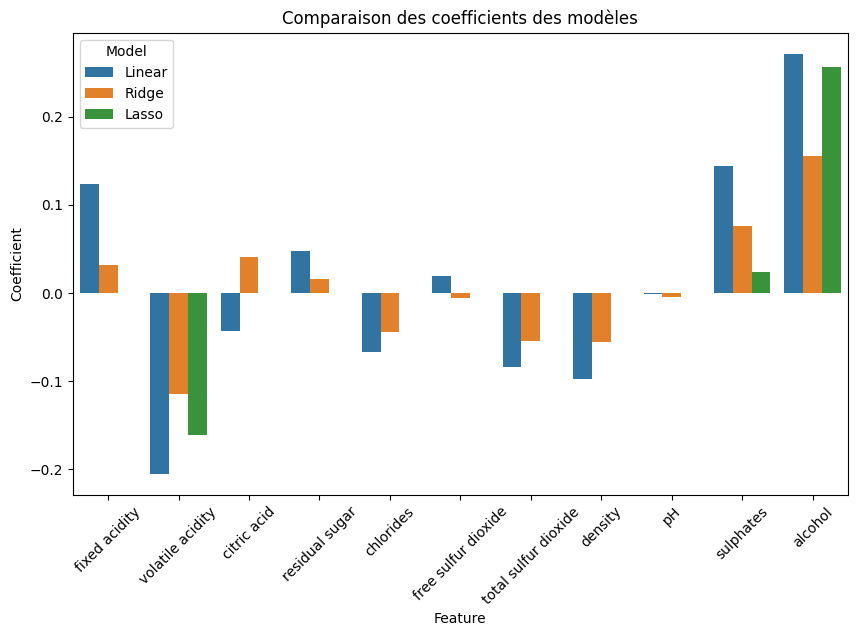

In [136]:
# Plot coefficients for each model
coefficients = pd.DataFrame({
    'Feature': columns,
    'Linear': model_linear.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_
})
coefficients_melted = coefficients.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')
plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients_melted, x='Feature', y='Coefficient', hue='Model')
plt.xticks(rotation=45)
plt.title('Comparaison des coefficients des modèles')
plt.show()

In [137]:
from sklearn.preprocessing import KBinsDiscretizer

binner = KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile')
print(f'Original feature shape: {X_train.shape}')
X_binned = binner.fit_transform(X_train)
print(f'Binned feature shape: {X_binned.shape}')
model = LinearRegression()
model.fit(X_binned, y_train)
y_val_binned = binner.transform(X_val)
y_val_pred_binned = model.predict(y_val_binned)
val_mse_binned = np.mean((y_val - y_val_pred_binned) ** 2)
print(f'Binned Features Validation MSE: {val_mse_binned:.4f}')

Original feature shape: (959, 11)
Binned feature shape: (959, 55)
Binned Features Validation MSE: 0.4551


c:\Users\cleme\miniconda3\envs\torch\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


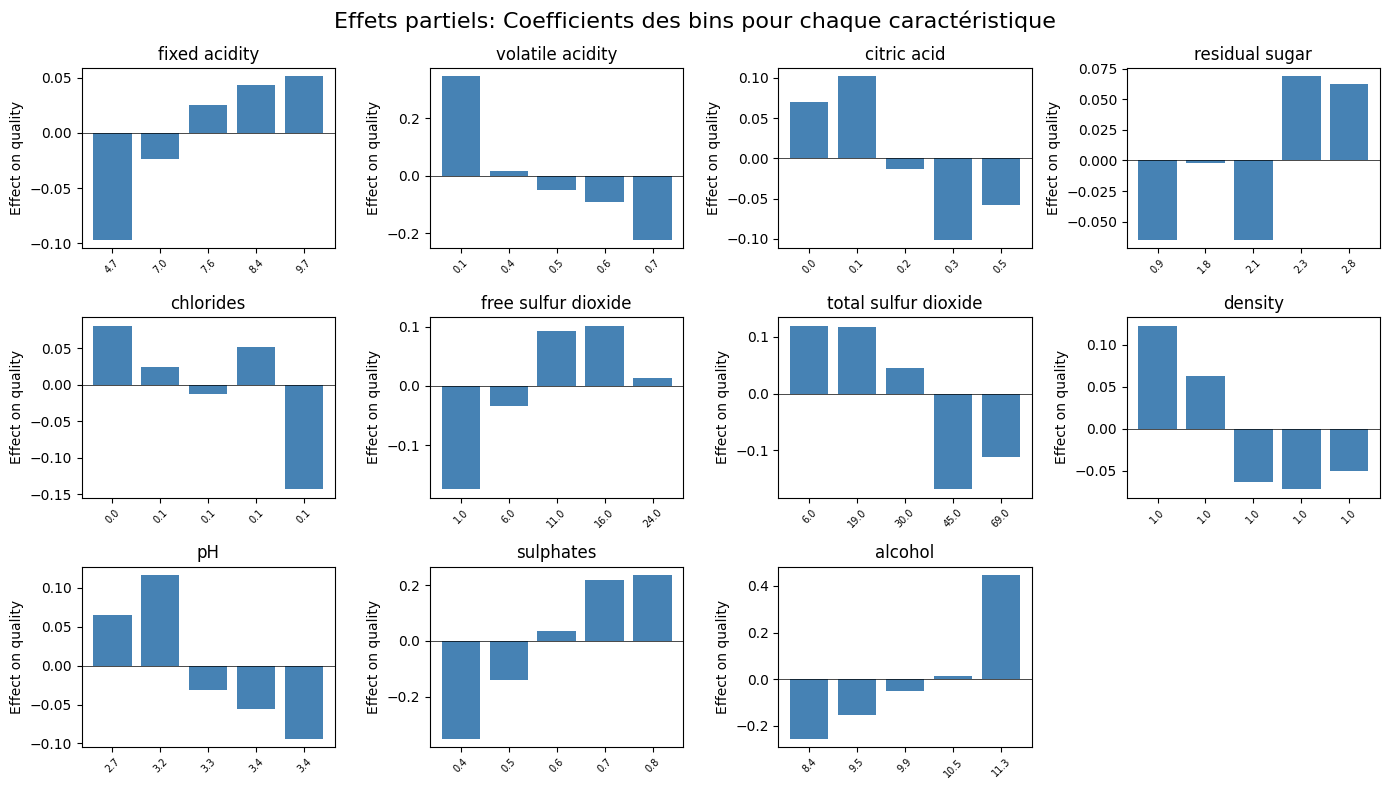

In [138]:

feature_names = X_train.columns  # or your list of feature names
n_bins = 5
n_features = len(feature_names)

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
axes = axes.flatten()

for j, fname in enumerate(feature_names):
    ax = axes[j]
    
    # Get coefficients for this feature's bins
    start_idx = j * n_bins
    coeffs = model.coef_[start_idx:start_idx + n_bins]
    
    # Get bin edges for x-axis labels
    edges = binner.bin_edges_[j]
    bin_centers = (edges[:-1] + edges[1:]) / 2
    
    ax.bar(range(n_bins), coeffs, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(fname)
    ax.set_xticks(range(n_bins))
    ax.set_xticklabels([f'{edges[i]:.1f}' for i in range(n_bins)], fontsize=7, rotation=45)
    ax.set_ylabel('Effect on quality')

# Hide unused subplots
for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.suptitle('Effets partiels: Coefficients des bins pour chaque caractéristique', fontsize=16)
plt.tight_layout()
plt.show()

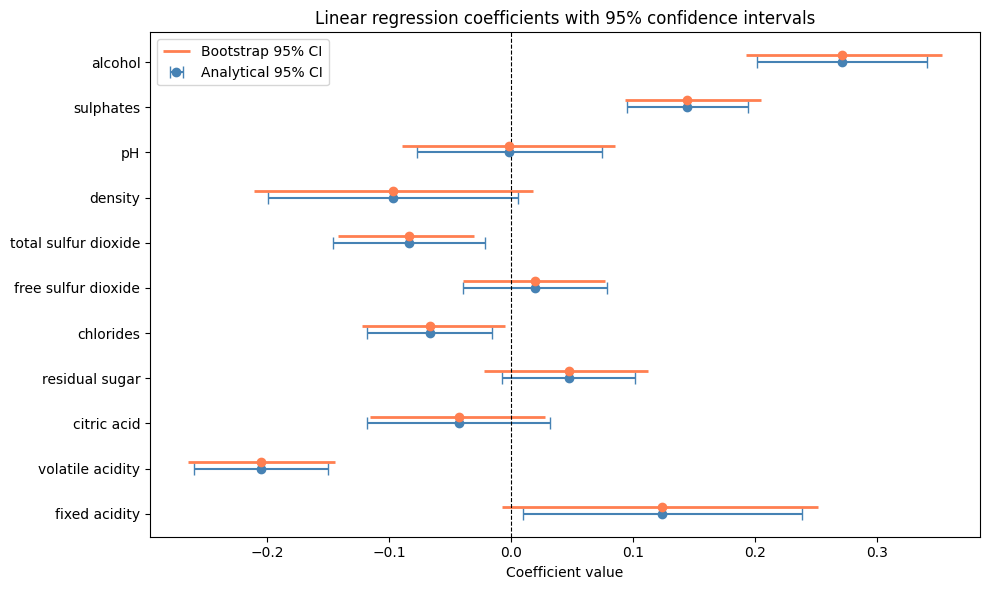

In [139]:
from scipy import stats

# Fit model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Residual variance estimate
y_pred = model.predict(X_train_scaled)
n, p = X_train_scaled.shape
residual_var = np.sum((y_train - y_pred) ** 2) / (n - p - 1)

# Covariance matrix of coefficients: σ² (XᵀX)⁻¹
XtX_inv = np.linalg.inv(X_train_scaled.T @ X_train_scaled)
coef_var = residual_var * XtX_inv
coef_std = np.sqrt(np.diag(coef_var))

# 95% confidence intervals
t_crit = stats.t.ppf(0.975, df=n - p - 1)
ci_low = model.coef_ - t_crit * coef_std
ci_high = model.coef_ + t_crit * coef_std


n_bootstrap = 1000
coefs_bootstrap = []

for _ in range(n_bootstrap):
    idx = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled[idx]
    y_boot = y_train.values[idx] if hasattr(y_train, 'values') else y_train[idx]
    
    model_boot = LinearRegression()
    model_boot.fit(X_boot, y_boot)
    coefs_bootstrap.append(model_boot.coef_)

coefs_bootstrap = np.array(coefs_bootstrap)
ci_low_boot = np.percentile(coefs_bootstrap, 2.5, axis=0)
ci_high_boot = np.percentile(coefs_bootstrap, 97.5, axis=0)



fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(feature_names))

# Plot coefficients with error bars
ax.errorbar(model.coef_, y_pos, xerr=[model.coef_ - ci_low, ci_high - model.coef_],
            fmt='o', capsize=4, label='Analytical 95% CI', color='steelblue')

# Add bootstrap CI as lighter bars
ax.hlines(y_pos + 0.15, ci_low_boot, ci_high_boot, color='coral', linewidth=2, label='Bootstrap 95% CI')
ax.scatter(model.coef_, y_pos + 0.15, color='coral', zorder=3)

ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_names)
ax.set_xlabel('Coefficient value')
ax.set_title('Linear regression coefficients with 95% confidence intervals')
ax.legend()

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Residuals vs Predicted')

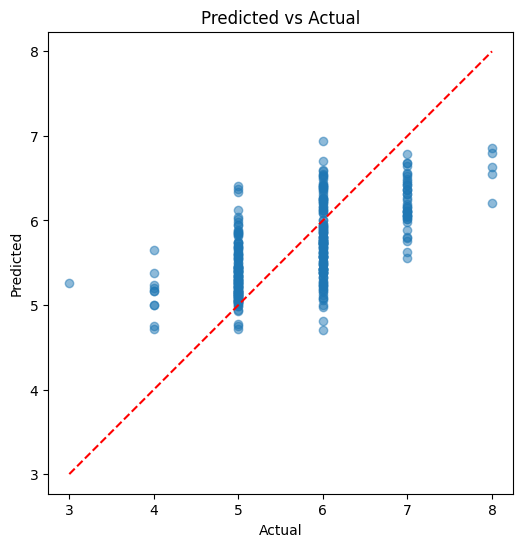

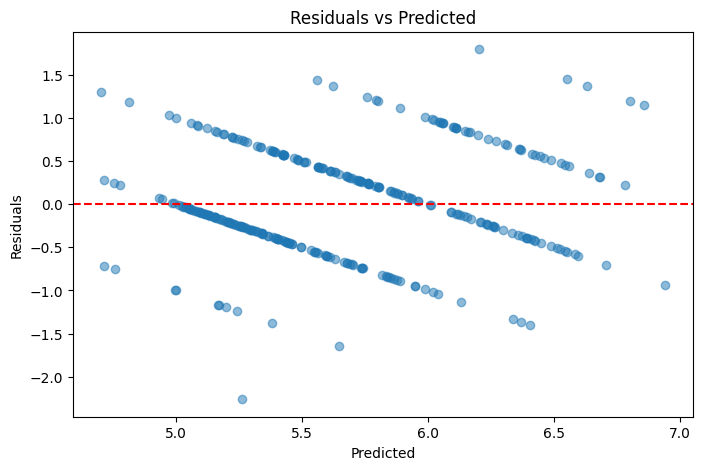

In [140]:
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.axis('equal')


residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')

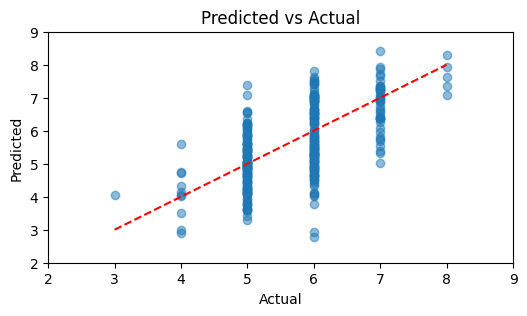

In [147]:
from sklearn.utils.class_weight import compute_sample_weight

weights = compute_sample_weight('balanced', y_train)
# weights = np.sqrt(weights)  # dampen extreme values

# Use weighted least squares manually:
W = np.diag(weights)
X = X_train_scaled
y = y_train

# Add intercept
X = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
X_test = np.column_stack([np.ones(len(X_test_scaled)), X_test_scaled])

W = np.diag(weights)
coeffs = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y_train
y_pred = X_test @ coeffs


plt.figure(figsize=(6, 3))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.xlim(2, 9)
plt.ylim(2, 9)
plt.show()



Ridge Validation MSE: 0.5036


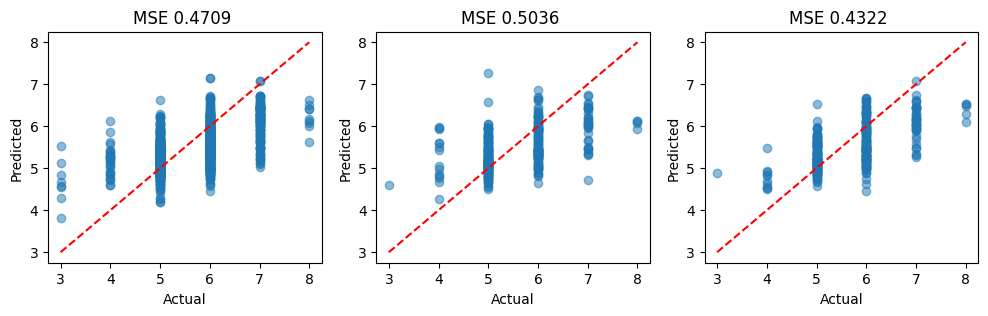

In [148]:
red_wine = pd.read_csv('winequality-red.csv', sep=';')
red_wine.head()
columns  = red_wine.columns.tolist()
columns.remove('quality')
X = red_wine[columns]
y = red_wine['quality']

# Interactions
X['alcohol_acidity'] = X['alcohol'] * X['volatile acidity']

# Polynomial terms for key features
X['alcohol_sq'] = X['alcohol'] ** 2

# Domain knowledge: acidity ratio
X['acidity_ratio'] = X['fixed acidity'] / X['volatile acidity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2
N = 10000 # Number of samples
X_train = X_train.iloc[:N]
y_train = y_train.iloc[:N]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

weights = compute_sample_weight('balanced', y_train)

# Explicitly weighted Ridge regression
ridge_model = Ridge(alpha=5.0*len(X_train))
ridge_model.fit(X_train_scaled, y_train, sample_weight=weights)
y_val_pred_ridge = ridge_model.predict(X_val_scaled)

val_mse_ridge = np.mean((y_val - y_val_pred_ridge) ** 2)
print(f'Ridge Validation MSE: {val_mse_ridge:.4f}')

# Plot pred vs actual for each set
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, X_set, y_set, title in zip(axes, 
                                   [X_train_scaled, X_val_scaled, X_test_scaled], 
                                   [y_train, y_val, y_test], 
                                   ['Training Set', 'Validation Set', 'Test Set']):
    y_pred = ridge_model.predict(X_set)
    ax.scatter(y_set, y_pred, alpha=0.5)
    ax.plot([y_set.min(), y_set.max()], [y_set.min(), y_set.max()], 'r--')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.set_title(f"MSE {np.mean((y_set - y_pred) ** 2):.4f} ")

